# 1. Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]



### 1.1. Inicialização

In [33]:
# Carregando todas as bibliotecas

import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

### 1.2. Carregue os dados

In [3]:
# Carregue os arquivos de dados em diferentes DataFrames

call = pd.read_csv('megaline_calls.csv')
internet = pd.read_csv('megaline_internet.csv')
messages = pd.read_csv('megaline_messages.csv')
plans = pd.read_csv('megaline_plans.csv')
users = pd.read_csv('megaline_users.csv')

### 1.3. Prepare os dados

Após o carregamento dos arquivos, será realizada a exploração e análise dos dados, bem como a correção de eventuais inconsistências, por meio da aplicação de métodos e funções adequados às necessidades identificadas.

### 1.4. Planos

In [4]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [5]:
# Imprima uma amostra de dados dos planos

print(plans.sample(2))

   messages_included  mb_per_month_included  minutes_included  \
1               1000                  30720              3000   
0                 50                  15360               500   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
1               70           7             0.01            0.01  ultimate  
0               20          10             0.03            0.03      surf  


Após previa analise realizada no arquivo, noto que não há muitos erros estruturais e não há dados duplicados ou ausentes. Sugiro que seja feita algumas correções nos tipo de algumas colunas afim de facilitar a leitura e compreensão dos dados.

### 1.5. Corrija os dados

Verificados os dados sugiro algumas alterações:

- Converter os dados da coluna 'mb_per_month_included' de MB para GB, e alterar o nome da coluna para 'gb_per_month_included'; (em analise feita no tópico 1.10 identifico que é melhor deixar a a unidade mb)

- Conversão das seguintes colunas 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message' e 'usd_per_minute, para o tipo de dado para float, pois se tratam de moedas. E Por fim, converter a coluna 'plan_name' para o tipo category.



In [6]:
# Convertendo os tipo de dados do DataFrame

plans['usd_monthly_pay'] = plans['usd_monthly_pay'].astype('float')
plans['usd_per_gb'] = plans['usd_per_gb'].astype('float')
plans['plan_name'] = plans['plan_name'].astype('category')
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   messages_included      2 non-null      int64   
 1   mb_per_month_included  2 non-null      int64   
 2   minutes_included       2 non-null      int64   
 3   usd_monthly_pay        2 non-null      float64 
 4   usd_per_gb             2 non-null      float64 
 5   usd_per_message        2 non-null      float64 
 6   usd_per_minute         2 non-null      float64 
 7   plan_name              2 non-null      category
dtypes: category(1), float64(4), int64(3)
memory usage: 370.0 bytes


##### Enriqueça os dados

Atribui os valores 0 e 1 para os nomes dos planos, poderia ser uma boa alternativa para futuras pesquisas.

### 1.7. Usuários

In [7]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprima uma amostra de dados dos usuários

print(users.sample(10))


     user_id first_name last_name  age  \
151     1151      Ralph    Monroe   21   
459     1459     Santos      Head   40   
67      1067       Robt     Allen   37   
16      1016       Jann   Salinas   30   
145     1145     Venice    Brooks   29   
439     1439      Moses   Cabrera   28   
473     1473       Kirk     Velez   61   
316     1316    Lucilla     Weeks   59   
436     1436    Jennine    Kinney   69   
211     1211       Vito   Cameron   60   

                                                city    reg_date      plan  \
151        New York-Newark-Jersey City, NY-NJ-PA MSA  2018-03-20      surf   
459           San Francisco-Oakland-Berkeley, CA MSA  2018-04-27  ultimate   
67                     Grand Rapids-Kentwood, MI MSA  2018-09-24      surf   
16                                    Fresno, CA MSA  2018-10-25      surf   
145           San Jose-Sunnyvale-Santa Clara, CA MSA  2018-04-12      surf   
439         Riverside-San Bernardino-Ontario, CA MSA  2018-01-04     

Apenas a coluna 'churn_date' possui dados ausentes. Nehumas delas possuem dados duplicados. No DataFrame exitem duas colunas que se referem a datas, nelas precisaremos alterar o tipo para datatime.

##### 1.7.1. Corrija os dados

In [9]:
# Tratando os valores ausentes e convertentdo 

# Coluna 'churn_date'
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

# Coluna 'reg_date'
users['reg_date'] = pd.to_datetime(users['reg_date'])

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


##### 1.7.2. Enriqueça os dados

A coluna 'city' poderia ser tratada com o objetivo de facilitar a leitura da região onde o plano foi adquirido. Com esses dados podemos analisar quais as regiões com maior adesão ao planos.

### 1.8. Chamadas

In [10]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas

call.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [11]:
# Imprima uma amostra de dados das chamadas

print(call.head())
print()
print(call.tail())
print()
print(call.sample(30))
print()
print(call.isna().sum())
print()
print(call.duplicated().sum())

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22

              id  user_id   call_date  duration
137730  1499_199     1499  2018-11-21      8.72
137731  1499_200     1499  2018-10-20     10.89
137732  1499_201     1499  2018-09-21      8.12
137733  1499_202     1499  2018-10-10      0.37
137734  1499_203     1499  2018-12-29     13.86

               id  user_id   call_date  duration
29951    1113_167     1113  2018-11-22      7.91
32750    1123_108     1123  2018-12-18      0.19
115512   1404_306     1404  2018-10-21      0.64
76858    1276_118     1276  2018-10-14      4.87
853      1004_378     1004  2018-07-16     11.69
66579    1240_437     1240  2018-11-18      6.15
77376    1277_452     1277  2018-09-14      2.67
7187     1033_203     1033  2018-10-04      8.65
119519   14

Ao analisar a amostra de dados identificamos que não há dados ausentes ou duplicados, mas notamos que existem colunas com o tipo de dados que dificultam uma análise mais detalhada. Para tratar esses problema será necessário verificar e realizar a conversão dos tipo de dados dessas colunas.

##### 1.8.1. Corrija os dados

Corrija problemas óbvios com os dados conforme as observações iniciais.

In [12]:
# Corrigindo o tipo de dados das colunas onservadas.

call['call_date'] = pd.to_datetime(call['call_date'], errors='coerce')

call.info()
print()

# verificando se a conversão é possível e não gera perda de dados
np.array_equal(call['id'], call['id'].astype('int'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB



False

##### 1.8.2. Enriqueça os dados

A conversão da coluna 'id', não é possível, pois podem haver perdas de informações. Com esses dados podemos ver a duração de tempo que cada cliente fez por mês, se ou ou não a necessidade de comprar mais pacote.

### 1.9. Mensagens

In [13]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [14]:
# Imprima uma amostra dos dados das mensagens

print(messages.head())
print()
print(messages.tail())
print()
print(messages.sample(30))

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26

             id  user_id message_date
76046  1497_526     1497   2018-12-24
76047  1497_536     1497   2018-12-24
76048  1497_547     1497   2018-12-31
76049  1497_558     1497   2018-12-24
76050  1497_613     1497   2018-12-23

             id  user_id message_date
65565  1421_150     1421   2018-11-21
60823  1382_588     1382   2018-09-21
69294   1450_73     1450   2018-12-12
12418  1081_170     1081   2018-09-05
26404  1159_407     1159   2018-09-18
73020  1470_648     1470   2018-06-24
7187    1059_57     1059   2018-06-27
37980   1251_32     1251   2018-04-02
70401   1458_40     1458   2018-09-30
49123   1328_81     1328   2018-07-16
69657   1454_19     1454   2018-09-07
16394  1110_285     1110   2018-09-26
32711  1203_356     1203   2018-08-04
58237   1369_38     1369   2018-12

Aqui também nota-se que a coluna 'messages' precisa de tratamento no tipo de dados.

##### 1.9.1. Corrija os dados

Corrija problemas óbvios com os dados conforme as observações iniciais.

In [15]:
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


##### 1.9.2. Enriqueça os dados

Aqui podemos verificar a quantidade de mensagens enviadas por usuario mensalmente e se houve necessidade de adicionar pacotes.

### 1.10. Internet

In [16]:
# Imprima informações gerais/resumo sobre o DataFrame da internet

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [17]:
#  Imprima uma amostra de dados para o tráfego da internet

print(internet.head())
print()
print(internet.tail())
print()
print(internet.sample(30))


         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22

              id  user_id session_date  mb_used
104820  1499_215     1499   2018-10-20   218.06
104821  1499_216     1499   2018-12-30   304.72
104822  1499_217     1499   2018-09-22   292.75
104823  1499_218     1499   2018-12-07     0.00
104824  1499_219     1499   2018-12-24   758.31

              id  user_id session_date  mb_used
6659    1038_147     1038   2018-12-17   723.82
9638     1050_57     1050   2018-05-06   568.22
30753    1141_16     1141   2018-12-20    63.56
87004   1403_352     1403   2018-08-26   652.49
33417   1151_159     1151   2018-10-16   100.09
51185   1231_114     1231   2018-09-16   860.53
5938     1032_99     1032   2018-12-02     4.03
15769   1071_419     1071   2018-06-12   549.60
56362   1254_404    

##### 1.10.1. Corrija os dados

Corrija problemas óbvios com os dados conforme as observações iniciais.

In [18]:
internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


##### 1.10.2. Enriqueça os dados

Chegando a essa etapa de analise, identifico que transformar MegaByte em GigaByte não seria tão eficaz. Então escolho não realizar a conversão.

### 1.11. Estude as condições dos planos

É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.

In [19]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você

print(plans.head())


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0             20.0        10.0             0.03            0.03      surf  
1             70.0         7.0             0.01            0.01  ultimate  


### 1.12. Agregue os dados por usuário

Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.

In [20]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.

call['mes'] = call['call_date'].dt.to_period('M')
qtd_calls = call.groupby(['user_id', 'mes']).size().reset_index(name="num_calls")
print(qtd_calls)

      user_id      mes  num_calls
0        1000  2018-12         16
1        1001  2018-08         27
2        1001  2018-09         49
3        1001  2018-10         65
4        1001  2018-11         64
...       ...      ...        ...
2253     1498  2018-12         39
2254     1499  2018-09         41
2255     1499  2018-10         53
2256     1499  2018-11         45
2257     1499  2018-12         65

[2258 rows x 3 columns]


In [22]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.

duration_calls = call.groupby(['user_id', 'mes'])['duration'].sum().reset_index(name="duration_calls")

print(duration_calls)

      user_id      mes  duration_calls
0        1000  2018-12          116.83
1        1001  2018-08          171.14
2        1001  2018-09          297.69
3        1001  2018-10          374.11
4        1001  2018-11          404.59
...       ...      ...             ...
2253     1498  2018-12          324.77
2254     1499  2018-09          330.37
2255     1499  2018-10          363.28
2256     1499  2018-11          288.56
2257     1499  2018-12          468.10

[2258 rows x 3 columns]


In [23]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

messages['mes'] = messages['message_date'].dt.to_period('M')
qtd_messages = messages.groupby(['user_id', 'mes'])['mes'].count().reset_index(name="num_messages")

print(qtd_messages)


      user_id      mes  num_messages
0        1000  2018-12            11
1        1001  2018-08            30
2        1001  2018-09            44
3        1001  2018-10            53
4        1001  2018-11            36
...       ...      ...           ...
1801     1496  2018-09            21
1802     1496  2018-10            18
1803     1496  2018-11            13
1804     1496  2018-12            11
1805     1497  2018-12            50

[1806 rows x 3 columns]


In [24]:
# Calcule o quantidade de internet enviadas por cada usuário por mês. Salve o resultado.

internet['mes'] = internet['session_date'].dt.to_period('M')

#print(internet.head(30))
qtd_internet = internet.groupby(['user_id', 'mes'])['mb_used'].sum().reset_index(name='mb_used')
print(qtd_internet)

      user_id      mes   mb_used
0        1000  2018-12   1901.47
1        1001  2018-08   6919.15
2        1001  2018-09  13314.82
3        1001  2018-10  22330.49
4        1001  2018-11  18504.30
...       ...      ...       ...
2272     1498  2018-12  23137.69
2273     1499  2018-09  12984.76
2274     1499  2018-10  19492.43
2275     1499  2018-11  16813.83
2276     1499  2018-12  22059.21

[2277 rows x 3 columns]


Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.

In [25]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

chamadas_total = qtd_calls.merge(duration_calls, on=['user_id', 'mes'], how='outer')
mensagens_total = chamadas_total.merge(qtd_messages, on=['user_id', 'mes'], how='outer')
internet_total = mensagens_total.merge(qtd_internet, on=['user_id', 'mes'], how='outer')

consumo_total = internet_total.fillna(0)

print(consumo_total.head(10))

   user_id      mes  num_calls  duration_calls  num_messages   mb_used
0     1000  2018-12       16.0          116.83          11.0   1901.47
1     1001  2018-08       27.0          171.14          30.0   6919.15
2     1001  2018-09       49.0          297.69          44.0  13314.82
3     1001  2018-10       65.0          374.11          53.0  22330.49
4     1001  2018-11       64.0          404.59          36.0  18504.30
5     1001  2018-12       56.0          392.93          44.0  19369.18
6     1002  2018-10       11.0           54.13          15.0   6552.01
7     1002  2018-11       55.0          359.76          32.0  19345.08
8     1002  2018-12       47.0          363.24          41.0  14396.24
9     1003  2018-12      149.0         1041.00          50.0  27044.14


In [26]:
# Adicione as informações sobre o plano

planos = users[['user_id', 'plan']]


consumo_total =  consumo_total.merge(planos, on='user_id', how='inner')

print(consumo_total.head(30))


    user_id      mes  num_calls  duration_calls  num_messages   mb_used  \
0      1000  2018-12       16.0          116.83          11.0   1901.47   
1      1001  2018-08       27.0          171.14          30.0   6919.15   
2      1001  2018-09       49.0          297.69          44.0  13314.82   
3      1001  2018-10       65.0          374.11          53.0  22330.49   
4      1001  2018-11       64.0          404.59          36.0  18504.30   
5      1001  2018-12       56.0          392.93          44.0  19369.18   
6      1002  2018-10       11.0           54.13          15.0   6552.01   
7      1002  2018-11       55.0          359.76          32.0  19345.08   
8      1002  2018-12       47.0          363.24          41.0  14396.24   
9      1003  2018-12      149.0         1041.00          50.0  27044.14   
10     1004  2018-05       21.0          181.58           7.0   6547.21   
11     1004  2018-06       44.0          261.32          18.0  20672.82   
12     1004  2018-07     

Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.

In [27]:
# Calcule a receita mensal para cada usuário

plans = {
     'surf': {
         'minutos': 500,
         'mensagens': 50,
         'internet': 15360,
         'preco': 20,
         'taxa_min_mensagem': 0.03,
         'taxa_internet': 10
     },
     'ultimate': {
         'minutos': 3000,
         'mensagens': 1000,
         'internet': 30720,
         'preco': 70,
         'taxa_min_mensagem': 0.01,
         'taxa_internet': 7
     }
}

def cal_fatura(row):
     plan = plans[row['plan']]
     total = plan['preco']

     if row['duration_calls'] > plan['minutos']:
         total += (row['duration_calls'] - plan['minutos']) * plan['taxa_min_mensagem']

     if row['num_messages'] > plan['mensagens']:
         total += (row['num_messages'] - plan['mensagens']) * plan['taxa_min_mensagem']

     if row['mb_used'] > plan['internet']:
         total += ((row['mb_used'] - plan['internet']) / 1024) * plan['taxa_internet']

     return  total

consumo_total['total_fatura'] = consumo_total.apply(cal_fatura, axis=1)
print(consumo_total.head(30))

    user_id      mes  num_calls  duration_calls  num_messages   mb_used  \
0      1000  2018-12       16.0          116.83          11.0   1901.47   
1      1001  2018-08       27.0          171.14          30.0   6919.15   
2      1001  2018-09       49.0          297.69          44.0  13314.82   
3      1001  2018-10       65.0          374.11          53.0  22330.49   
4      1001  2018-11       64.0          404.59          36.0  18504.30   
5      1001  2018-12       56.0          392.93          44.0  19369.18   
6      1002  2018-10       11.0           54.13          15.0   6552.01   
7      1002  2018-11       55.0          359.76          32.0  19345.08   
8      1002  2018-12       47.0          363.24          41.0  14396.24   
9      1003  2018-12      149.0         1041.00          50.0  27044.14   
10     1004  2018-05       21.0          181.58           7.0   6547.21   
11     1004  2018-06       44.0          261.32          18.0  20672.82   
12     1004  2018-07     

In [28]:
consumo_total.isna().sum()

user_id           0
mes               0
num_calls         0
duration_calls    0
num_messages      0
mb_used           0
plan              0
total_fatura      0
dtype: int64

### 1.13. Estude o comportamento do usuário

Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.

Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.

##### 1.13.1. Chamadas

plan
surf        404.762390
ultimate    406.193083
Name: duration_calls, dtype: float64


<Axes: title={'center': 'Média por plano - Duração de Chamadas'}, xlabel='Planos', ylabel='Duração de chamadas'>

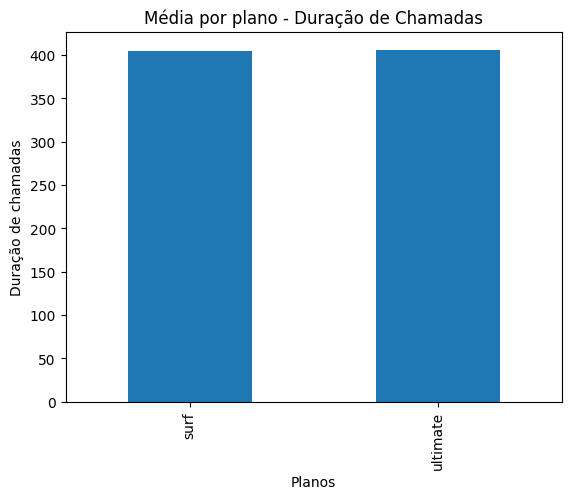

In [29]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

duration_mean_plan = consumo_total.groupby('plan')['duration_calls'].mean()
print(duration_mean_plan)

duration_mean_plan.plot(kind='bar',
                        title='Média por plano - Duração de Chamadas',
                        xlabel='Planos',
                        ylabel='Duração de chamadas'
                        )


         duration_calls
user_id                
1001            1640.46
1002             777.13
1003            1041.00
1004            2618.95
1005             470.22
...                 ...
1494            2672.66
1495            1666.41
1496            1376.21
1498            3029.97
1499            1450.31

[333 rows x 1 columns]
         duration_calls
user_id                
1000             116.83
1006              64.11
1008            1473.31
1011            2744.87
1013             203.37
...                 ...
1482             786.62
1487             392.71
1490            2123.33
1493            2197.37
1497             276.53

[157 rows x 1 columns]


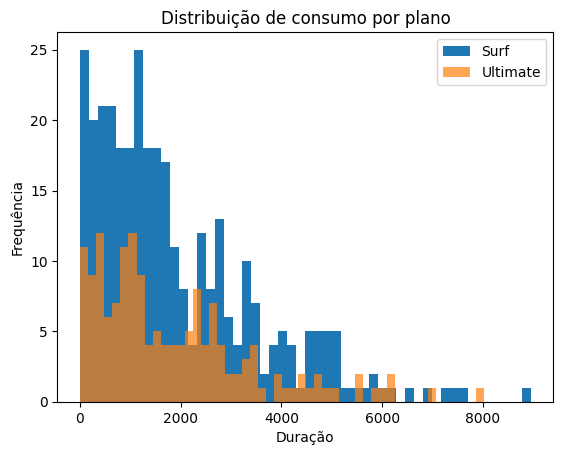

In [30]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.

plano_surf = consumo_total.query("plan == 'surf'")[['user_id', 'duration_calls']]
consumo_plano_surf = plano_surf.groupby('user_id')[['duration_calls']].sum()
print(consumo_plano_surf)

plano_ultimate = consumo_total.query("plan == 'ultimate'")[['user_id', 'duration_calls']]
consumo_plano_ultimate = plano_ultimate.groupby('user_id')[['duration_calls']].sum()
print(consumo_plano_ultimate)

plt.hist(consumo_plano_surf, bins=50, label='Surf')
plt.hist(consumo_plano_ultimate, bins=50, alpha=0.7, label='Ultimate')
plt.xlabel('Duração')
plt.ylabel('Frequência')
plt.title('Distribuição de consumo por plano')
plt.legend()
plt.show()

Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.

In [31]:
# Calcule a média e a variância da duração mensal das chamadas

# Calcula da Média
mean_duration_calls_month = consumo_total.groupby('mes')[['duration_calls']].mean()
print(mean_duration_calls_month)

# Calculo da Variância
variance = np.var(mean_duration_calls_month['duration_calls'])
print()
print('A variância é de ', variance)


         duration_calls
mes                    
2018-01      186.388333
2018-02      324.168125
2018-03      302.306571
2018-04      327.685493
2018-05      378.862075
2018-06      388.474861
2018-07      417.719889
2018-08      390.248884
2018-09      397.839893
2018-10      411.711079
2018-11      406.066829
2018-12      442.818849

A variância é de  4504.3543263302045


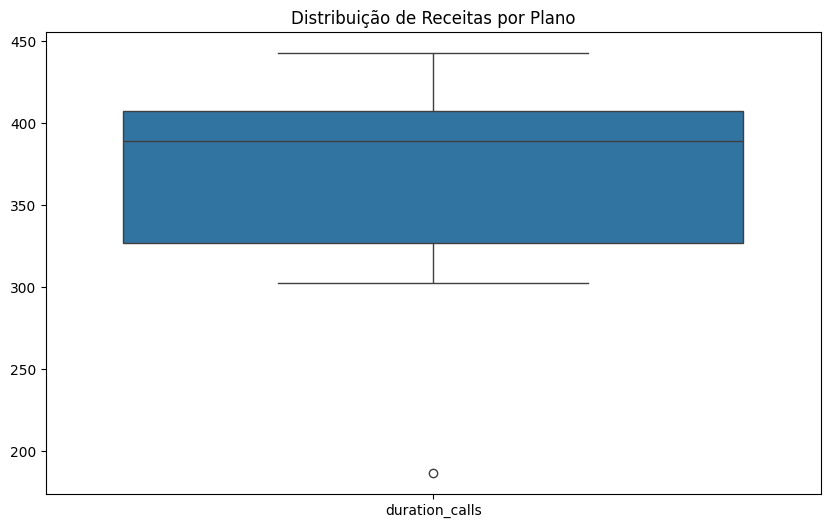

In [32]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

plt.figure(figsize=(10, 6))
sns.boxplot(data=mean_duration_calls_month)
plt.title('Distribuição de Receitas por Plano')
plt.show()


Quando comparado em volume total a média entre os dois planos é muito próxima. Já quando exploramos mais os dados percebemos que grande parte dos clientes do plano surf tem um alto consumo e muitas vezes ultrapassam os limites do plano. Existe também um alto grau de dispersão em torno da média mensal, vemos isso no resultado que a variância nos fornece. Com o gráfico de caixa vemos que existe E analisando o gráfico de caixa podemos informar que a distribuição é relativamente simétrica em torno da mediana, existe uma pequena dispersão, e notamos a existência de um mês atípico ande usa média fica fora dos limites do gráfico de caixa.

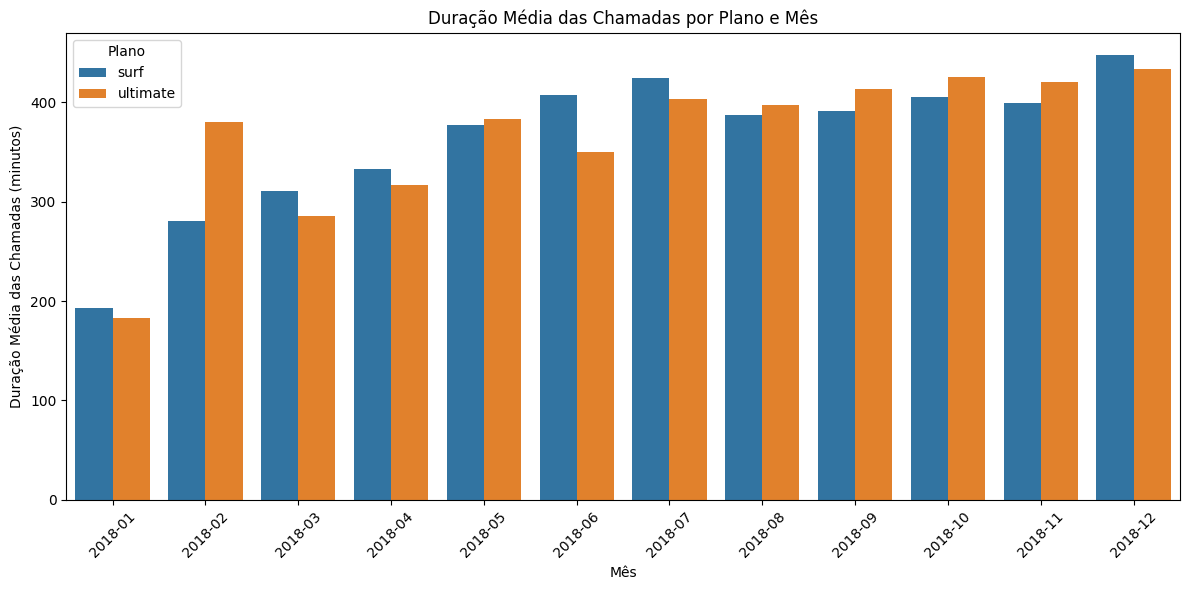

In [34]:
avg_minutes = consumo_total.groupby(['plan', 'mes'])['duration_calls'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=avg_minutes, x='mes', y='duration_calls', hue='plan')

plt.title('Duração Média das Chamadas por Plano e Mês')
plt.xlabel('Mês')
plt.ylabel('Duração Média das Chamadas (minutos)')
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.tight_layout()
plt.show()

##### 1.13.2. Mensagens

In [36]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
# PLANO SURF

plano_surf_message = consumo_total.query("plan == 'surf'")[['user_id', 'mes', 'num_messages']]
consumo_message_surf = plano_surf_message.groupby(['user_id', 'mes'])[['num_messages']].sum()
print((consumo_message_surf.head(30)))

                 num_messages
user_id mes                  
1001    2018-08          30.0
        2018-09          44.0
        2018-10          53.0
        2018-11          36.0
        2018-12          44.0
1002    2018-10          15.0
        2018-11          32.0
        2018-12          41.0
1003    2018-12          50.0
1004    2018-05           7.0
        2018-06          18.0
        2018-07          26.0
        2018-08          25.0
        2018-09          21.0
        2018-10          24.0
        2018-11          25.0
        2018-12          31.0
1005    2018-12          11.0
1007    2018-08          51.0
        2018-09          47.0
        2018-10          59.0
        2018-11          48.0
        2018-12          50.0
1009    2018-05           0.0
        2018-06           0.0
        2018-07           0.0
        2018-08           0.0
        2018-09           0.0
        2018-10           0.0
        2018-11           0.0


In [37]:
# PLANO ULTIMATE

plano_ultimate_message = consumo_total.query("plan == 'ultimate'")[['user_id', 'mes', 'num_messages']]
consumo_message_ultimate = plano_ultimate_message.groupby(['user_id', 'mes'])[['num_messages']].sum()
print(consumo_message_ultimate.head(30))
print(consumo_message_ultimate.min())
print(consumo_message_ultimate.max())

                 num_messages
user_id mes                  
1000    2018-12          11.0
1006    2018-11          15.0
        2018-12         139.0
1008    2018-10          21.0
        2018-11          37.0
        2018-12          26.0
1011    2018-06          21.0
        2018-07          53.0
        2018-08          54.0
        2018-09          60.0
        2018-10          64.0
        2018-11          58.0
        2018-12          61.0
1013    2018-12          16.0
1026    2018-07           9.0
        2018-08          13.0
1028    2018-02          12.0
        2018-03          66.0
        2018-04          77.0
        2018-05          84.0
        2018-06          66.0
        2018-07          85.0
        2018-08          74.0
        2018-09          68.0
        2018-10          73.0
        2018-11          77.0
        2018-12          74.0
1030    2018-10           9.0
        2018-11          11.0
        2018-12          10.0
num_messages    0.0
dtype: float64
num_m

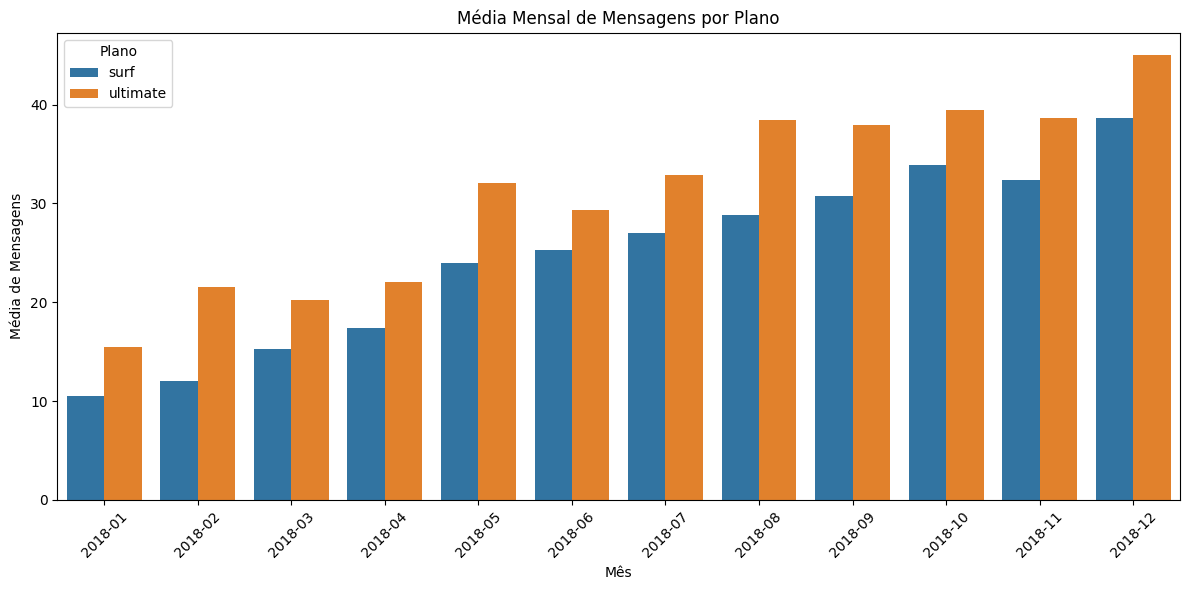

In [38]:
avg_num_messages = consumo_total.groupby(['plan', 'mes'])['num_messages'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=avg_num_messages, x='mes', y='num_messages', hue='plan')

plt.title('Média Mensal de Mensagens por Plano')
plt.xlabel('Mês')
plt.ylabel('Média de Mensagens')
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.tight_layout()
plt.show()

Os clientes do plano Surf possuem a quantidade de mensagens dentro do limite para o seu plano, ocorre em alguns casos a necessidade de comprar mais dados extras. Já os cliente do plano Ultimate utilizam uma quantia bem inferior ao limite do plano.

##### 1.13.3. Internet

In [39]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
# plano surf

plano_surf_internet = consumo_total.query("plan == 'surf'")[['user_id', 'mb_used']]
consumo_internet_surf = plano_surf_internet.groupby(['user_id'])[['mb_used']].sum()
print(consumo_internet_surf)
print('O consumo total de internet do plano surf  é: ', consumo_internet_surf['mb_used'].sum())
print(consumo_internet_surf.min())
print(consumo_internet_surf.max())

           mb_used
user_id           
1001      80437.94
1002      40293.33
1003      27044.14
1004     156352.81
1005      17140.17
...            ...
1494      91389.19
1495      98890.96
1496      64268.64
1498     227525.13
1499      71350.23

[333 rows x 1 columns]
O consumo total de internet do plano surf  é:  26046179.93
mb_used    0.0
dtype: float64
mb_used    312518.64
dtype: float64


In [40]:
# plano Ultimate

plano_ultimate_internet = consumo_total.query("plan == 'ultimate'")[['user_id', 'mb_used']]
consumo_internet_ultimate = plano_ultimate_internet.groupby(['user_id'])[['mb_used']].sum()
print(consumo_internet_ultimate)
print('O consumo total de internet do plano Ultimate  é: ', consumo_internet_ultimate['mb_used'].sum())

           mb_used
user_id           
1000       1901.47
1006      34187.19
1008      55473.04
1011     131778.60
1013      20113.92
...            ...
1482      20806.13
1487      13992.39
1490     190904.51
1493      76378.43
1497      11106.55

[157 rows x 1 columns]
O consumo total de internet do plano Ultimate  é:  12394583.779999997


O plano Surf consome mais do dobro do consumo do plano Ultimate.

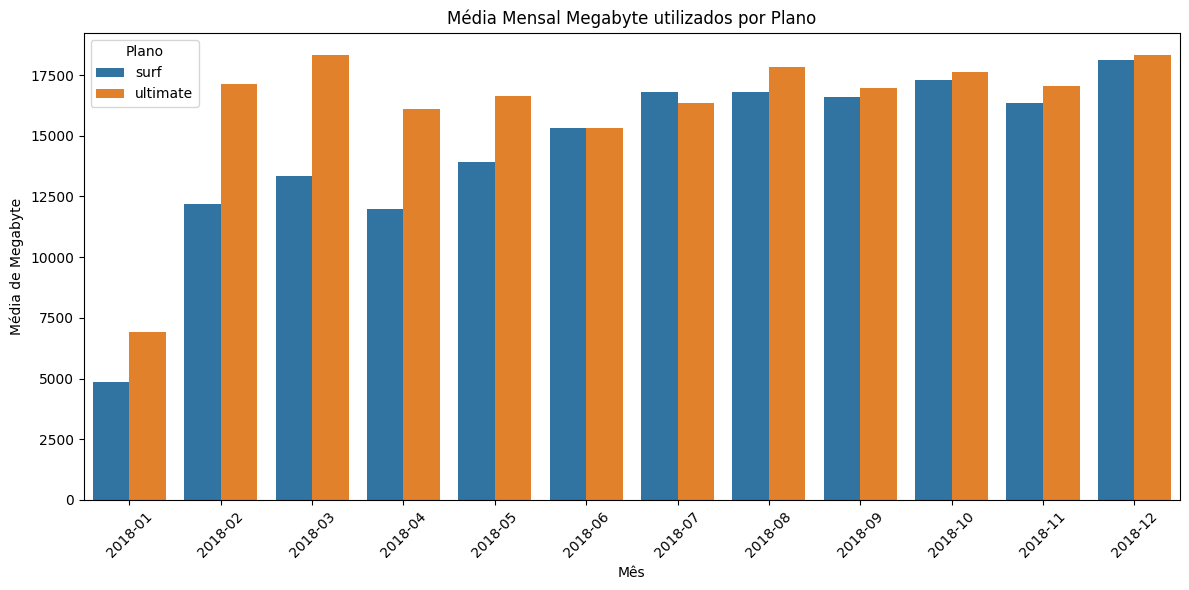

In [41]:
avg_internet_used = consumo_total.groupby(['plan', 'mes'])['mb_used'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=avg_internet_used, x='mes', y='mb_used', hue='plan')

plt.title('Média Mensal Megabyte utilizados por Plano')
plt.xlabel('Mês')
plt.ylabel('Média de Megabyte')
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.tight_layout()
plt.show()

### 1.14. Receita

Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.

In [42]:
# RECEITA TOTAL PLANO SURF

receita_plano_surf = consumo_total.query("plan == 'surf'")[['user_id', 'mes', 'total_fatura']]
receita_surf = receita_plano_surf.groupby(['user_id', 'mes'])[['total_fatura']].sum()
print(receita_surf)
print('A RECEITA TOTAL DO PLANO SURF É: ', receita_surf['total_fatura'].sum())


                 total_fatura
user_id mes                  
1001    2018-08     20.000000
        2018-09     20.000000
        2018-10     88.161191
        2018-11     50.706055
        2018-12     59.152148
...                       ...
1498    2018-12     95.954004
1499    2018-09     20.000000
        2018-10     60.355762
        2018-11     34.197559
        2018-12     85.421973

[1573 rows x 1 columns]
A RECEITA TOTAL DO PLANO SURF É:  90123.12233828125


A RECEITA TOTAL DO PLANO SURF É:  90123.12233828125

In [43]:
# RECEITA TOTAL PLANO ULTIMATE

receita_plano_ultimate = consumo_total.query("plan == 'ultimate'")[['user_id', 'mes', 'total_fatura']]
receita_ultimate = receita_plano_ultimate.groupby(['user_id', 'mes'])[['total_fatura']].sum()
print(receita_ultimate)
print('A RECEITA TOTAL DO PLANO ULTIMATE É: ', receita_ultimate['total_fatura'].sum())

                 total_fatura
user_id mes                  
1000    2018-12     70.000000
1006    2018-11     70.000000
        2018-12     79.562246
1008    2018-10     70.000000
        2018-11     70.000000
...                       ...
1493    2018-09     70.000000
        2018-10     70.000000
        2018-11     70.000000
        2018-12     70.000000
1497    2018-12     70.000000

[720 rows x 1 columns]
A RECEITA TOTAL DO PLANO ULTIMATE É:  51923.57734375


A RECEITA TOTAL DO PLANO ULTIMATE É:  51923.57734375

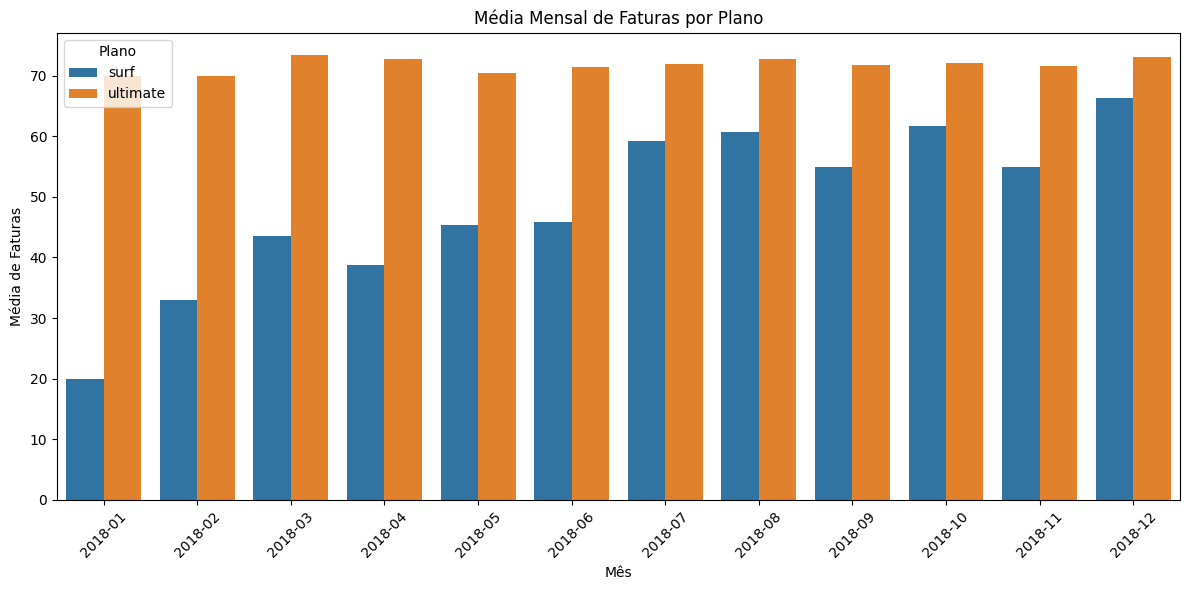

In [44]:
avg_fatura = consumo_total.groupby(['plan', 'mes'])['total_fatura'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=avg_fatura, x='mes', y='total_fatura', hue='plan')

plt.title('Média Mensal de Faturas por Plano')
plt.xlabel('Mês')
plt.ylabel('Média de Faturas')
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.tight_layout()
plt.show()


A os dados da receita também nos mostram que que o plano surf fatura mais que o plano Ultimate. E que os clientes do plano Surf ultrapassam os limites do planos.

### 1.15. Teste hipóteses estatísticas

Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.

Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.



In [45]:
# Teste as hipóteses '[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes
# 1. FOMULAÇÃO DAS HIPÓTESES
#
# H0 - A receita média dos usuários dos planos Ultimate e Surf são iguais
# H1 - A receita média dos usuários dos planos Ultimate e Surf são diferentes

alpha = 0.05

# 2. Média de receita por usuário por plano
# PLANO SURF

receita_plano_surf = consumo_total.query("plan == 'surf'")[['user_id', 'total_fatura']]
receita_surf = receita_plano_surf.groupby(['user_id'])[['total_fatura']].mean()
mean_plano_surf = receita_surf['total_fatura'].mean()
print(receita_surf)
print('A RECEITA MÉDIA POR CLIENTE DO PLANO SURF É: ', mean_plano_surf)

print()
print()


# PLANO ULTIMATE

receita_plano_ultimate = consumo_total.query("plan == 'ultimate'")[['user_id', 'total_fatura']]
receita_ultimate = receita_plano_ultimate.groupby(['user_id'])[['total_fatura']].mean()
mean_plano_ultimate = receita_ultimate['total_fatura'].mean()
print(receita_surf)
print('A RECEITA MÉDIA POR CLIENTE DO PLANO ULTIMATE É: ', mean_plano_ultimate)

print()
print()


         total_fatura
user_id              
1001        47.603879
1002        32.972266
1003       150.332930
1004        72.617151
1005        37.384473
...               ...
1494        28.565493
1495       112.018233
1496        24.117695
1498        72.483975
1499        49.993823

[333 rows x 1 columns]
A RECEITA MÉDIA POR CLIENTE DO PLANO SURF É:  54.9936103837267


         total_fatura
user_id              
1001        47.603879
1002        32.972266
1003       150.332930
1004        72.617151
1005        37.384473
...               ...
1494        28.565493
1495       112.018233
1496        24.117695
1498        72.483975
1499        49.993823

[333 rows x 1 columns]
A RECEITA MÉDIA POR CLIENTE DO PLANO ULTIMATE É:  71.66137174048782




A RECEITA MÉDIA POR CLIENTE DO PLANO ULTIMATE É:  71.66137174048782

In [46]:
#test_hipotese = st.ttest_ind(receita_surf, receita_ultimate, equal_var=False)

equal_var = receita_ultimate.values.var() == receita_surf.values.var()
test_hipotese = st.ttest_ind(receita_surf['total_fatura'], receita_ultimate['total_fatura'], equal_var=equal_var)
print('Valor-p: ', test_hipotese.pvalue)

if test_hipotese.pvalue > alpha:
    print('H0 NÃO deve ser rejeitada (aceita)')
else:
    print('H0 deve ser REJEITADA')



Valor-p:  1.2784012613632527e-11
H0 deve ser REJEITADA


Neste caso H0 deve ser REJEITADA.

In [47]:
users = users[['user_id', 'city']]
region_user = users[users['city'].str.contains('NY-NJ')]
print(region_user['city'])

14     New York-Newark-Jersey City, NY-NJ-PA MSA
22     New York-Newark-Jersey City, NY-NJ-PA MSA
24     New York-Newark-Jersey City, NY-NJ-PA MSA
27     New York-Newark-Jersey City, NY-NJ-PA MSA
31     New York-Newark-Jersey City, NY-NJ-PA MSA
                         ...                    
469    New York-Newark-Jersey City, NY-NJ-PA MSA
482    New York-Newark-Jersey City, NY-NJ-PA MSA
494    New York-Newark-Jersey City, NY-NJ-PA MSA
495    New York-Newark-Jersey City, NY-NJ-PA MSA
498    New York-Newark-Jersey City, NY-NJ-PA MSA
Name: city, Length: 80, dtype: object


In [48]:
Consumo_NY_NJ = consumo_total.merge(region_user, on='user_id')
print(Consumo_NY_NJ)
print('A receita total dos cliente da região NY e NJ é: ', Consumo_NY_NJ['total_fatura'].sum())

     user_id      mes  num_calls  duration_calls  num_messages   mb_used  \
0       1014  2018-11       28.0          149.33           9.0   1175.59   
1       1014  2018-12      150.0         1050.62          64.0   7792.41   
2       1022  2018-05       39.0          287.34           0.0   4908.08   
3       1022  2018-06       76.0          455.45           0.0  23436.48   
4       1022  2018-07       70.0          448.25           0.0   9933.15   
..       ...      ...        ...             ...           ...       ...   
372     1498  2018-08       44.0          244.57           0.0  20261.89   
373     1498  2018-09       45.0          344.62           0.0  22827.28   
374     1498  2018-10       46.0          278.06           0.0  20580.76   
375     1498  2018-11       41.0          208.99           0.0  19168.55   
376     1498  2018-12       39.0          324.77           0.0  23137.69   

     plan  total_fatura                                       city  
0    surf     20.0

A receita total dos cliente da região NY e NJ é:  21560.812603125003

In [49]:
merged = pd.merge(consumo_total, users, on='user_id')
idx = merged['city'].str.contains('NY-NJ')
ny_nj = merged[idx]
not_ny_nj = merged[~idx]

ny_nj['total_fatura'].var() == not_ny_nj['total_fatura'].var() 

np.False_

In [50]:
print(ny_nj['total_fatura'].var())
print(not_ny_nj['total_fatura'].var())

1777.7529232966267
2116.1719888966627


In [51]:
equal_var = ny_nj['total_fatura'].var() == not_ny_nj['total_fatura'].var() 
test_hipotese_2 = st.ttest_ind(ny_nj['total_fatura'], not_ny_nj['total_fatura'], equal_var=equal_var)
print('Valor-p: ', test_hipotese_2.pvalue)

if test_hipotese_2.pvalue > alpha:
    print('H0 NÃO deve ser rejeitada (aceita)')
else:
    print('H0 deve ser REJEITADA')


Valor-p:  0.018609472974972074
H0 deve ser REJEITADA


# Conclusão Geral

As análise e testes realizados ao logo deste trabalho mostrou que:

- Os usuários posuem uma média de receita significativa independente do plao como mostra o tete de hipótese;
- O plano Surf por ser mais barato, parece ser uma boa opção para o cliente, mas os hábitos dos clientes mostram o contrário. Neste plano a necessidade de compra de dados extras é muito grande. Chegando a ultrapassar até a mensalidade do plano Ultimate em alguns casos. O plano surf é mais rentável para a empresa por visando que pode gerar cobranças adicionais;
- O plano Ultimate tende a garantir uma receita mais estável e alta por usuário, já que tem mensalidade fixa elevada e excedentes raramente ultrapassam os limites incluídos;
- O plano Surf é uma forma de for atrair mais clientes com preço de entrada baixo, o Surf pode ser mais competitivo.
